In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import xarray as xr
from parametrizations import *
import numpy as np
import cartopy.crs as ccrs

In [ ]:
#XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5, 6]_latent_dims=3_past_timesteps=20/20251215092753_global_ocean_land_rp=False_eps=1.0_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy')
grid = xr.open_dataset('/work/bd1179/b309297/DYAMOND_experiment/DYAMOND/icon_grid_0019_R02B05_G.nc')

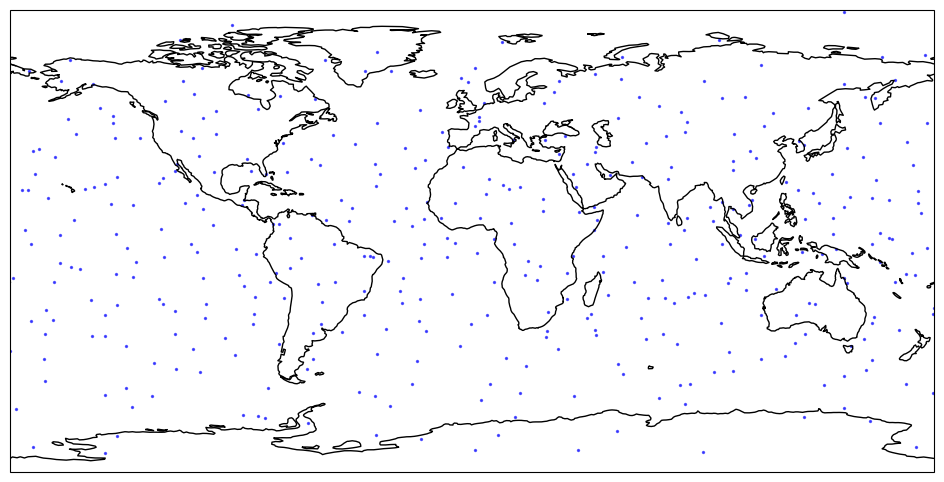

In [9]:
skip = 200
lon = np.rad2deg(grid.clon.values)[::skip]
lat = np.rad2deg(grid.clat.values)[::skip]
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# 3. Adding map features
ax.coastlines(resolution='110m', linewidth=1)
scatter = ax.scatter(lon, lat, s=2, color='blue', alpha=0.6, 
                     transform=ccrs.PlateCarree(), label=f'Grid Points (skip={skip})')

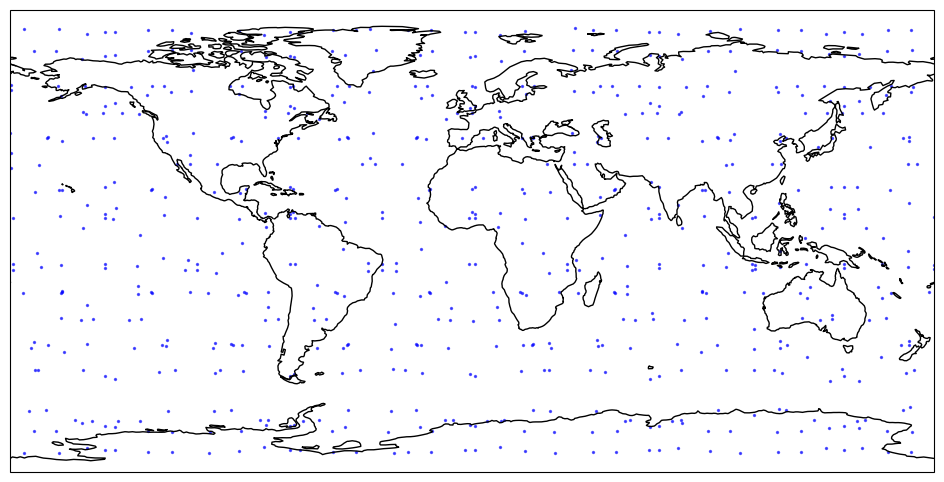

In [8]:
lon = np.rad2deg(grid.clon.values)
lat = np.rad2deg(grid.clat.values)

# desired spacing in degrees (tune this)
dlon = 10.0
dlat = 10.0

lon_bin = np.floor(lon / dlon)
lat_bin = np.floor(lat / dlat)

# unique spatial bins
_, unique_idx = np.unique(
    np.stack([lon_bin, lat_bin], axis=1),
    axis=0,
    return_index=True
)

lon_sub = lon[unique_idx]
lat_sub = lat[unique_idx]

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# 3. Adding map features
ax.coastlines(resolution='110m', linewidth=1)
scatter = ax.scatter(lon_sub, lat_sub, s=2, color='blue', alpha=0.6, 
                     transform=ccrs.PlateCarree(), label=f'Grid Points (skip={skip})')

In [4]:
# Set device to gpu if avaible, else to cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
grid = xr.open_dataset('/work/bd1179/b309297/DYAMOND_experiment/DYAMOND/icon_grid_0019_R02B05_G.nc')
ds = xr.open_dataset('merged_15min_ICON-NWP-2km_DW-ATM_r1i1p1f1_2d_gn_20200120000000-20200301000000_R02B05.nc')
grid = grid.assign_coords(
    clon=("cell", np.rad2deg(grid.clon.values)),
    clat=("cell", np.rad2deg(grid.clat.values))
)
ds = ds.assign_coords(
    clon=("cell", np.rad2deg(ds.clon.values)),
    clat=("cell", np.rad2deg(ds.clat.values))
)

# Compute 15-min precipitation increment → convert to mm/h
precip = ds.pracc.diff('time') * 4
precip.name = 'precip'
precip.attrs.update({
    'long_name': 'Precipitation rate',
    'units': 'mm h-1',
    'description': 'Derived from accumulated precipitation (15-min difference)'
})

# Drop the first timestep from the dataset to align with `precip` and add new variable
ds = ds.isel(time=slice(1, None))
ds['precip'] = precip

# Regional masks
tropical_ocean_mask = (grid.cell_sea_land_mask==-2) & (grid.clat<=23) & (grid.clat>=-23)
global_ocean_mask = (grid.cell_sea_land_mask==-2)
tropical_ocean_land_mask = (grid.clat<=23) & (grid.clat>=-23)
global_ocean_land_mask = (grid.clat<=180) & (grid.clat>=-180)

# Regional prepitating mask
precip_threshold = 0.05  # mm/h
tropical_ocean_precipitating_mask = (ds.precip >= precip_threshold) & tropical_ocean_mask
global_ocean_precipitating_mask = (ds.precip >= precip_threshold) & global_ocean_mask
tropical_ocean_land_precipitating_mask = (ds.precip >= precip_threshold) & tropical_ocean_land_mask
global_ocean_land_precipitating_mask = (ds.precip >= precip_threshold) & global_ocean_land_mask

ds

<xarray.Dataset> Size: 10GB
Dimensions:    (cell: 81920, nv: 3, time: 3897, height: 1)
Coordinates:
  * time       (time) datetime64[ns] 31kB 2020-01-20T00:15:00 ... 2020-03-01
    clon       (cell) float64 655kB 73.0 73.91 72.09 73.0 ... 75.27 75.96 76.78
    clat       (cell) float64 655kB 52.62 52.93 52.93 ... -45.21 -44.22 -45.17
  * height     (height) float64 8B 2.0
Dimensions without coordinates: cell, nv
Data variables:
    clon_bnds  (cell, nv) float64 2MB ...
    clat_bnds  (cell, nv) float64 2MB ...
    hfls       (time, cell) float32 1GB ...
    hfss       (time, cell) float32 1GB ...
    huss       (time, height, cell) float32 1GB ...
    pracc      (time, cell) float32 1GB ...
    prw        (time, cell) float32 1GB ...
    tas        (time, height, cell) float32 1GB ...
    ts         (time, cell) float32 1GB ...
    precip     (time, cell) float32 1GB 0.0001063 0.0004139 ... 0.001953 0.2562
Attributes:
    CDI:                       Climate Data Interface version 2.2.4 (https://...
    Conventions:               CF-1.6
    number_of_grid_used:       19
    grid_file_uri:             http://icon-downloads.mpimet.mpg.de/grids/publ...
    uuidOfHGrid:               e941b1d0-ab58-11e8-ba4f-bdd1e82b9e6d
    institution:               Max Planck Institute for Meteorology
    history:                   Fri Oct 17 16:45:07 2025: cdo merge hfls.nc hf...
    cdo_openmp_thread_number:  4
    CDO:                       Climate Data Operators version 2.2.2 (https://...

In [ ]:
ds.isel()

TypeError: can only lookup dictionaries from Dataset.loc

In [4]:
# Model classes
class BaseParametrization:
    def __init__(self, n_features, past_timesteps, latent_dims, memory_indices):
        super().__init__()

        # Parametrization params
        self.latent_dims = latent_dims
        self.past_timesteps = past_timesteps
        self.memory_indices = memory_indices
        if self.memory_indices:
            self.n_memory_features = len(self.memory_indices)
        else:
            self.n_memory_features = 0
        self.n_features = n_features
        self.model_name = None
        
        # training params
        self.weight_decay = None
        self.learning_rate = None
        self.train_loss = []
        self.test_loss = []
        self.R2 = []
    
    def save(self, additional_info=None):
        # Save the model
        save_dir = Path(f'networks/{self.model_name}/n_features={self.n_features}_memory_indices={self.memory_indices}_latent_dims={self.latent_dims}_past_timesteps={self.past_timesteps}')
        if not save_dir.exists(): 
            os.makedirs(save_dir) 
        
        timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
        if additional_info:
            save_file = f'{timestamp}_{additional_info}.pkl'
        else:
            save_file = f'{timestamp}.pkl'
        save_path = f'{save_dir}/{save_file}'
        torch.save(self, save_path)
        
        return save_path

class NNpAEpD(nn.Module, BaseParametrization):
    def __init__(self, n_features, past_timesteps, latent_dims, memory_indices, nodes_per_layer=16):
        nn.Module.__init__(self)
        BaseParametrization.__init__(self, n_features, past_timesteps, latent_dims, memory_indices,)
        
        self.nodes_per_layer = nodes_per_layer
        self.model_name = 'NN+AE+D'

        self.encoder = nn.Sequential(
            nn.Linear(self.past_timesteps * self.n_memory_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 12),
            nn.ReLU(),
            nn.Linear(12, self.latent_dims)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dims, 12),
            nn.ReLU(),
            nn.Linear(12, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, self.past_timesteps * self.n_memory_features)
        )

        self.neural_net = nn.Sequential(
            nn.Linear(latent_dims + self.n_features, self.nodes_per_layer), 
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, 1)
        )

    def forward(self, x_memory, x_present):
        latent_space = self.encoder(x_memory)
        x_reconstructed = self.decoder(latent_space)
        x_nn = torch.cat((latent_space, x_present), dim=1)
        y_pred = self.neural_net(x_nn)
        
        return y_pred, x_reconstructed

class NNbase(nn.Module, BaseParametrization):
    def __init__(self, n_features, past_timesteps=0, latent_dims=0, memory_indices=None, nodes_per_layer=16):
        nn.Module.__init__(self)
        BaseParametrization.__init__(self, n_features, past_timesteps, latent_dims, memory_indices)
        
        self.nodes_per_layer = nodes_per_layer
        self.model_name = 'NNbase'

        self.neural_net = nn.Sequential(
            nn.Linear(self.n_features, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, 1)
        )
    
    def forward(self, x_present):
        return self.neural_net(x_present)

In [5]:
tmax = None
training_mask = tropical_ocean_land_mask
X = torch.tensor(np.array([ds.huss.values[:,0,training_mask], ds.prw.values[:, training_mask], 
                           ds.tas.values[:,0,training_mask], ds.ts.values[:, training_mask], 
                           ds.hfss.values[:, training_mask], ds.hfls.values[:, training_mask],
                           ds.precip.values[:, training_mask]]), dtype=torch.float32)[:, :tmax, :]
# X = torch.tensor(np.array([ds.huss.values[:,0,tropical_ocean_mask], ds.prw.values[:, tropical_ocean_mask], 
#                            ds.tas.values[:,0,tropical_ocean_mask], ds.ts.values[:, tropical_ocean_mask]]), dtype=torch.float32)[:, :tmax, :]
# Y = torch.tensor(np.array(ds.precip.values[:, tropical_ocean_mask]), dtype=torch.float32)[:tmax, :]

In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, past_timesteps, time_series_length):
        """
        X: torch.Tensor of shape (Nfeatures, NT, num_coords)
        Y: torch.Tensor of shape (NT, num_coords)
        past_timesteps: int, number of past timesteps per sample
        """
        self.X = X
        self.past_timesteps = past_timesteps
        self.Nfeatures, self.NT, self.num_coords = X.shape
        self.time_series_length = time_series_length
        self.num_samples = int((self.NT - self.past_timesteps) / self.time_series_length)  # include present
        print((self.NT - self.past_timesteps) / self.time_series_length)

    def __len__(self):
        return self.num_coords * self.num_samples

    def __getitem__(self, idx):
        """
        Returns:
            x_window: shape (time_series_length + past_timesteps,)
            b_target: scalar
        """
        coord = idx // self.num_samples       # which coordinate
        time_idx = idx % self.num_samples     # which time step

        tstart =  time_idx * self.time_series_length 
        tend = tstart + self.time_series_length + self.past_timesteps
        x_window = self.X[:, tstart: tend, coord]
        # y_target = self.Y[tstart: tend, coord]  # present value

        return x_window #, y_target


def train_test_split(X, train_ind):
    return X[:,:train_ind], X[:,train_ind:]


def generate_dataloaders(X, model, time_series_length=100, train_share=.8, batch_size=64, num_workers=1):
    train_ind = int(X.shape[1] * train_share)
    X_train, X_test = X[:,:train_ind], X[:,train_ind:]
    
    # Create datasets
    train_dataset = TimeSeriesDataset(X_train, model.past_timesteps, time_series_length=time_series_length)
    test_dataset = TimeSeriesDataset(X_test, model.past_timesteps, time_series_length=time_series_length)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True, drop_last=False, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False, drop_last=False, pin_memory=True, persistent_workers=True)

    return train_loader, test_loader

In [7]:
# Model training
def reconstruction_loss(x_batch, x_present, y_batch, model, criterion, reconstruction_criterion, alpha):
    b_pred, x_recon = model(x_batch, x_present)
    loss = alpha * criterion(b_pred, y_batch) + (1 - alpha) * reconstruction_criterion(x_recon, x_batch)
    return loss

def prediction_loss(_, x_batch, y_batch, model, criterion):
    b_pred = model(x_batch)
    loss = criterion(b_pred, y_batch)
    return loss

def process_past_timesteps(x, n_features, past_timesteps, mask_memory, mask_present):
    x = x.to(device)
    X_lag = x.permute(2, 0, 1)  # change dimension order to (time, batch, variable)
    X_lag = X_lag.unfold(0, past_timesteps + 1, 1)  # create lagged features, exclude present timestep to align with X_present
    X_lag = X_lag.reshape(-1, (n_features + 1) * (past_timesteps + 1))
    X_present = X_lag[:, mask_present]
    Y = X_present[:, -1].reshape(-1, 1)  # Precip is safed as the last variable
    X_present = X_present[:, :-1]  # Drop target from features
    X_lag = X_lag[:, mask_memory]
    return X_lag.to(device), X_present.to(device), Y.to(device)    

def process_NN(x_batch, y_batch, n_features):
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    x_batch = x_batch.transpose(1, 2)  # Swap feature and time series dimension
    x_batch = x_batch.reshape(-1, n_features)  # Add time series dimension to batch dimension
    y_batch = y_batch.reshape(-1, 1)  # Add time series dimension to batch dimension
    return x_batch, None, y_batch


def get_mask_past_present(model):
    mask_memory = torch.zeros((model.n_features + 1, model.past_timesteps + 1), dtype=torch.bool, device='cpu')
    mask_present = torch.zeros((model.n_features + 1, model.past_timesteps + 1), dtype=torch.bool, device='cpu')
    mask_present[:, -1] = True  # only get last value
    mask_present = mask_present.flatten()
    mask_memory[model.memory_indices] = True  # only get variables from desired indices
    mask_memory[:, -1] = False  # discard present value
    mask_memory = mask_memory.flatten()
    return mask_memory, mask_present

def train_model(train_loader, test_loader, model, num_epochs=5, weight_decay=1.e-6):
    model = model.to(device)
    criterion = nn.MSELoss()
    lr = 0.0005
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    model.learning_rate = lr
    model.weight_decay = weight_decay

    pbar = trange(num_epochs, desc="Training", ncols=150)
    # Set loss function
    if model.model_name == 'NN+AE+D':
        reconstruction_criterion = nn.MSELoss()
        loss_func = reconstruction_loss
        alpha = 1.0
        loss_args = (reconstruction_criterion, alpha)
    else:
        loss_func = prediction_loss
        loss_args = ()
    
    # Set preprocessing function
    if model.model_name in ['NN+AE+D', 'NNbase']:
        process_func = process_past_timesteps
        mask_memory, mask_present = get_mask_past_present(model)
        process_args = (model.n_features, model.past_timesteps, mask_memory, mask_present)
    
    for epoch in pbar:
        model.train()
        total_train_loss = 0.0

        # Iterate over batches
        for x_batch in train_loader:
            # Preprocessing
            x_batch, x_present, y = process_func(x_batch, *process_args)
            # Compute loss
            loss = loss_func(x_batch, x_present, y, model, criterion, *loss_args)

            # Back propagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        # Validation
        model.eval()
        total_test_loss = 0.0
        with torch.no_grad():
            for x_batch in test_loader:
                # Preprocessing
                x_batch, x_present, y = process_func(x_batch, *process_args)

                # Compute loss
                loss = loss_func(x_batch, x_present, y, model, criterion, *loss_args)
                total_test_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_test_loss = total_test_loss / len(test_loader)
        model.train_loss.append(avg_train_loss)
        model.test_loss.append(avg_test_loss)

        pbar.set_postfix({
            "Train Loss": f"{avg_train_loss:.4f}",
            "Test Loss": f"{avg_test_loss:.4f}"
            })

    return model

In [ ]:
model = NNpAEpD(n_features=6, past_timesteps=2, latent_dims=5, memory_indices=[0, 1, 2, 3, 4, 5])
trainloader, testloader = generate_dataloaders(X, model, batch_size=100, num_workers=10, time_series_length=200, train_share=0.8)
print(len(testloader))
model = train_model(trainloader, testloader, model, num_epochs=60)
model.save('tropical_ocean')

15.575
3.89
687


Training: 100%|██████████████████████████████████████████████████████████████████| 60/60 [18:36<00:00, 18.60s/it, Train Loss=0.2080, Test Loss=0.2166]


'networks/NN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=2/20251020140453_tropical_ocean.pkl'

In [31]:
model_base = NNbase(6, 0, 0, None)
trainloader, testloader = generate_dataloaders(X, model_base, batch_size=1000, num_workers=10, time_series_length=200, train_share=0.8)
model_base = train_model(trainloader, testloader, model_base, num_epochs=60)
#model_base.save('tropical_ocean')

15.585
3.9


Training:  80%|████████████████████████████████████████████████████▊             | 48/60 [01:59<00:29,  2.50s/it, Train Loss=0.2896, Test Loss=0.2879]
Exception in thread Thread-56 (_pin_memory_loop):
Traceback (most recent call last):
  File "/work/bd1179/b309297/conda_envs/DYAMOND_env/lib/python3.13/threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/work/bd1179/b309297/conda_envs/DYAMOND_env/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "/work/bd1179/b309297/conda_envs/DYAMOND_env/lib/python3.13/threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/work/bd1179/b309297/conda_envs/DYAMOND_env/lib/python3.13/site-packages/torch/utils/data/_utils/pin_memory.py", line 61, in _pin_memory_loop
    do_one_step()
    ~~~~~~~~~~~^^
  File "/work/bd1179/b309297/conda_envs/DYAMOND_en

KeyboardInterrupt: 

In [26]:
model = torch.load('./networks/NN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=2/20251020140453_tropical_ocean.pkl', map_location=device, weights_only=False)
model_base = torch.load('./networks/NNbase/n_features=6_memory_indices=None_latent_dims=0_past_timesteps=0/20251020140642_tropical_ocean.pkl', map_location=device, weights_only=False)

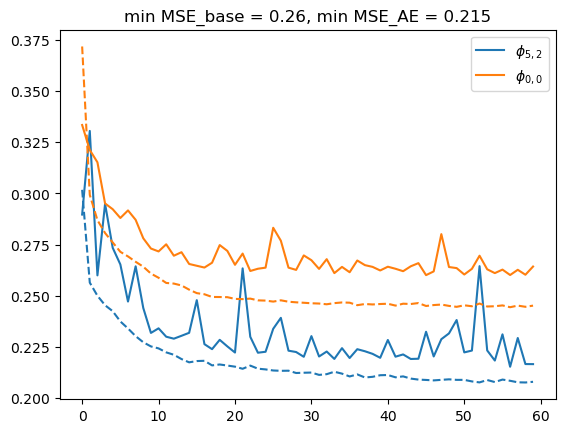

In [18]:
plt.plot(model.train_loss, color='tab:blue', linestyle='--')
plt.plot(model.test_loss, color='tab:blue', linestyle='-', label=r'$\phi_{5, 2}$')
plt.plot(model_base.train_loss, color='tab:orange', linestyle='--')
plt.plot(model_base.test_loss, color='tab:orange', linestyle='-', label=r'$\phi_{0, 0}$')
plt.title(f'min MSE_base = {round(min(model_base.test_loss), 3)}, min MSE_AE = {round(min(model.test_loss), 3)}')
plt.legend()
#plt.ylim(0, 1)

In [22]:
model.model_name

'NN+AE+D'

In [ ]:

def compute_R2(X, model, time_series_length=200, train_share=0.8, batch_size=100_000):
    trainloader, testloader = generate_dataloaders(X, model, time_series_length=time_series_length, train_share=train_share, batch_size=batch_size, num_workers=1)
    for x_batch in testloader:
        pass

    mask_memory, mask_present = get_mask_past_present(model)
    x_batch, x_present, y = process_past_timesteps(x_batch, model.n_features, model.past_timesteps, mask_memory, mask_present)
    if model.model_name == 'NNbase':
        y_pred = model.forward(x_present)
    elif model.model_name == 'NN+AE+D':
        y_pred, _ = model.forward(x_batch, x_present)

    return float(R2Score()(y_pred, y).detach().cpu())

print(compute_R2(X, model))
print(compute_R2(X, model_base))

NN+AE+D
15.575
3.89


0.5024450421333313
NNbase
15.585
3.9
0.42500340938568115


In [24]:
X_flatt = X.reshape(4, -1).T
Y_flatt = Y.reshape(-1, 1)
print(Y_flatt.shape)
train_ind = int(X_flatt.shape[0] * .8)
X_train, X_test = X_flatt[:train_ind].to(device), X_flatt[train_ind:].to(device)
Y_train, Y_test = Y_flatt[:train_ind].to(device), Y_flatt[train_ind:].to(device)

model.eval()
with torch.no_grad():
    y_pred = model.forward(X_test)
    R2_test = R2Score()(y_pred, Y_test)
    print('R2 test ', float(R2_test))

    y_pred = model.forward(X_train)
    R2_train = R2Score()(y_pred, Y_train)
    print('R2 train ', float(R2_train))

torch.Size([89225712, 1])
R2 test  0.42528730630874634
R2 train  0.40236443281173706


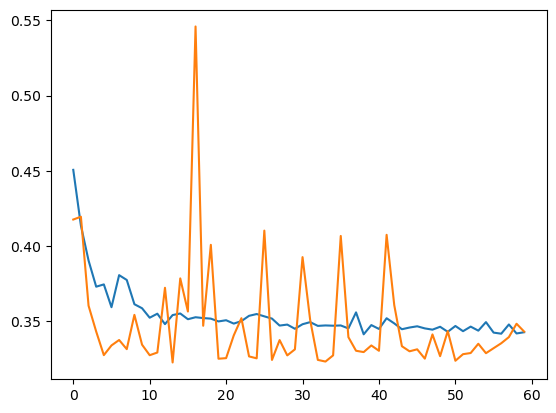

In [25]:
plt.plot(model.train_loss)
plt.plot(model.test_loss)

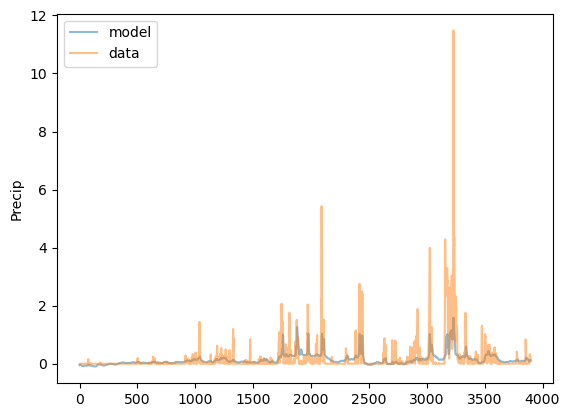

In [47]:
coord = np.random.randint(0, 20158, size=1)[0]
x = X[:, :, coord].T
y = Y[:, coord].reshape(-1, 1)
with torch.no_grad():
    y_pred = model.forward(x.to(device))
y_pred = y_pred.detach().cpu().numpy().flatten()
plt.plot(y_pred, label='model', alpha=.5)
plt.plot(y.detach().cpu().numpy().flatten(), label='data', alpha=.5)
plt.ylabel('Precip')
plt.legend()

23717
tensor(0.2473, device='cuda:0')


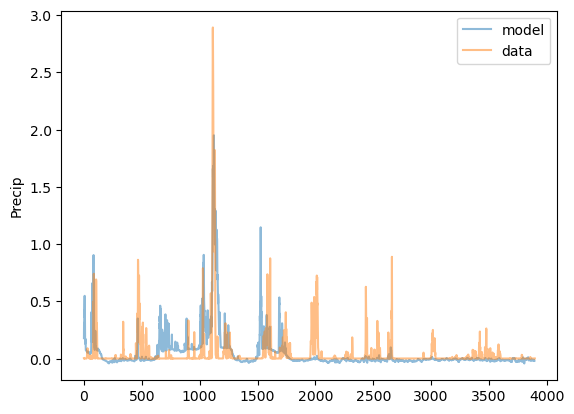

In [97]:
coord = np.random.randint(0, 80_000, size=1)[0]
print(coord)
x = X[:, :, coord].T
y = Y[:, coord].reshape(-1, 1)

x_pres = x[:-4]
x_sel = x[:, 1]
x_lag = x_sel.unfold(0, 4 + 1, 1)[:,:-1]

with torch.no_grad():
    y_pred, _ = model.forward(x_lag.to(device), x_pres.to(device))
    R2 = R2Score()(y_pred, y[:-4].to(device))
    print(R2)

y_pred = y_pred.detach().cpu().numpy().flatten()
plt.plot(y_pred, label='model', alpha=.5)
plt.plot(y.detach().cpu().numpy().flatten(), label='data', alpha=.5)
plt.ylabel('Precip')
plt.legend()


In [61]:
model_base = torch.load('/work/bd1179/b309297/DYAMOND_experiment/DYAMOND/networks/NNbase/n_features=4_memory_indices=None_latent_dims=0_past_timesteps=0/20251009110741.pkl', weights_only=False)
model = torch.load('/work/bd1179/b309297/DYAMOND_experiment/DYAMOND/networks/NN+AE+D/n_features=4_memory_indices=[1]_latent_dims=2_past_timesteps=4/20251009131547.pkl', weights_only=False)

(0.0, 1.0)

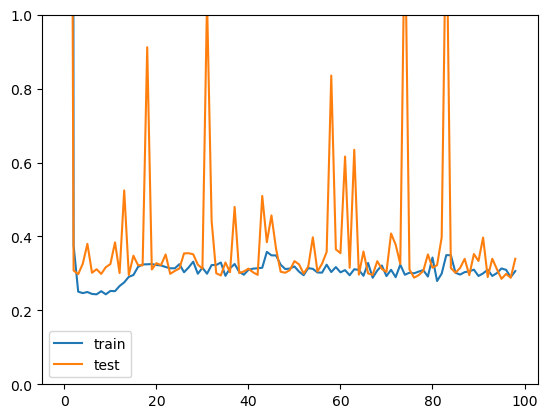

In [51]:
plt.plot(model.train_loss[1:], label='train')
plt.plot(model.test_loss[1:], label='test')
#plt.title(rf'baseline NN $R^2={R2_test}$')
plt.legend()
plt.ylim(0, 1)

In [ ]:
X_flatt = X.reshape(4, -1).T
Y_flatt = Y.reshape(-1, 1)
train_ind = int(X_flatt.shape[0] * .5)
X_train, X_test = X_flatt[:train_ind].to(device), X_flatt[train_ind:].to(device)
Y_train, Y_test = Y_flatt[:train_ind].to(device), Y_flatt[train_ind:].to(device)

model.eval()
with torch.no_grad():
    y_pred = model.forward(X_train)
    R2_train = R2Score()(y_pred, Y_train)
    print('R2 train ', float(R2_train))
    
    y_pred, _ = model.forward(X_test)
    R2_test = R2Score()(y_pred, Y_test)
    print('R2 test ', float(R2_test))

R2 train  0.29704463481903076


In [62]:
print(X.shape)
tmax = 2000
X_pres = X[:, tmax:-4]
X_pres = X_pres.permute(1, 2, 0).reshape(-1, 4)
print(X_pres.shape)
X_sel = X[:, tmax:]
print(X_sel.shape)
X_sel = X_sel.unfold(1, 4 + 1, 1)
print(X_sel.shape)
X_sel = X_sel.permute(1, 2, 0, 3)
X_sel = X_sel.reshape(-1, 5)[:, :-1]
X_sel = X_sel.reshape(-1, 16)
print(X_sel.shape)
Y_score = Y[tmax:-4].reshape(-1, 1)

model.eval()
with torch.no_grad():
    y_pred, _ = model.forward(X_sel.to(device), X_pres.to(device))
    R2_test = R2Score()(y_pred.to(device), Y_score.to(device))
    print('R2 test ', float(R2_test))

    # y_pred = model.forward(X_train)
    # R2_train = R2Score()(y_pred, Y_train)
    # print('R2 train ', float(R2_train))

torch.Size([4, 3897, 20158])
torch.Size([38159094, 4])
torch.Size([4, 1897, 20158])
torch.Size([4, 1893, 20158, 5])
torch.Size([38159094, 16])
R2 test  0.1840108036994934


In [72]:
X_sel.numpy()[:10, :4]

array([[0.01562825, 0.01563415, 0.01565624, 0.01569119],
       [0.01525215, 0.01524282, 0.01524039, 0.01525077],
       [0.01621071, 0.01624464, 0.0162915 , 0.01633877],
       [0.01534928, 0.01533163, 0.01531856, 0.01530859],
       [0.01583945, 0.01588587, 0.01594831, 0.01602608],
       [0.01538758, 0.0154018 , 0.01542037, 0.01543649],
       [0.01529726, 0.01528628, 0.01528142, 0.01528165],
       [0.01657479, 0.01662053, 0.01664321, 0.01665616],
       [0.01597924, 0.01601617, 0.01605195, 0.01608972],
       [0.01659063, 0.01660876, 0.01662505, 0.01663559]], dtype=float32)

In [15]:
model = None

In [41]:
tens = torch.randn((12, 4, 100))
memory_inds = [0, 2]

# x_fold = torch.stack([tens[:,i,:].unfold(1, 10, 1).reshape(-1, 10) for i in memory_inds], dim=1).flatten(start_dim=1)
# x_fold.shape

In [46]:
past_timesteps = 5  # tp
batch_size = 64  # B
N_features = 4 
memory_inds = [0, 2, 1, 3]
N_memory_features = len(memory_inds)  # Nm

x_sel = tens[:, memory_inds, :]  # (64, 2, 100)
x_unf = x_sel.unfold(-1, past_timesteps + 1, 1)  # unfold allong time dimension -> (B * (T-tp), Nm * tp, )
x_unf = x_unf.transpose(2, 1)  # swap axis order for simple reshape operation
x_fold = x_unf.reshape(-1, N_memory_features * (past_timesteps + 1))  # combine memory_idx and unfold windows

cols_to_remove = [m*(past_timesteps + 1) - 1 for m in range(1, N_memory_features + 1)]
mask = torch.ones(x_fold.size(1), dtype=torch.bool, device=x_fold.device)
print(x_fold.size(1), x_fold.shape)
mask[cols_to_remove] = False
x_fold = x_fold[:, mask]
x_fold

24 torch.Size([1140, 24])


tensor([[-0.6875,  0.4253,  1.3292,  ...,  1.2655,  0.2501,  0.6762],
        [ 0.4253,  1.3292,  0.6947,  ...,  0.2501,  0.6762,  1.0919],
        [ 1.3292,  0.6947, -1.7191,  ...,  0.6762,  1.0919, -1.4026],
        ...,
        [ 0.2993, -0.9320,  0.3508,  ..., -0.1779, -1.6388,  0.7212],
        [-0.9320,  0.3508, -0.5204,  ..., -1.6388,  0.7212,  0.7285],
        [ 0.3508, -0.5204,  0.6544,  ...,  0.7212,  0.7285,  1.3495]])

In [ ]:
x_fold[2]

tensor([1.4620e-04, 1.4642e-04, 1.4673e-04, 1.4707e-04, 1.4760e-04, 2.3886e+02,
        2.3887e+02, 2.3890e+02, 2.3892e+02, 2.3893e+02, 2.3274e+00, 2.3560e+00,
        2.3704e+00, 2.3851e+00, 2.4136e+00])

In [234]:
x_trunc = x[:, :, past_timesteps:]
x_T = x_trunc.transpose(1, 2)
x_input = x_T.reshape(-1, N_features)
print(x_input.shape)
x_input[2]

torch.Size([6080, 4])


tensor([1.4760e-04, 2.4263e+00, 2.3895e+02, 2.3809e+02])

In [66]:
Y_subset.shape

torch.Size([3897, 81920])

In [20]:
for x, y in trainloader:
    pass

In [ ]:
num_epochs = 1000
model = NNbase(4, 0, 0)
model = model.to(device)
criterion = nn.MSELoss()
# lr = 0.007
lr = 0.007
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1.e-6)
model.learning_rate = lr
best_R2 = float('-inf')
best_R2_epoch = 0
pbar = trange(num_epochs, desc="Training", ncols=150)
for epoch in pbar:
    model.train()
    Y_pred = model.forward(X_train)
    loss = criterion(Y_pred, Y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss = loss.item()

    model.eval()
    with torch.no_grad():
        Y_pred = model.forward(X_test)
        loss = criterion(Y_pred, Y_test)
        R2 = R2Score().to(device)(Y_pred, Y_test)
        test_loss = loss.item()
    
    if R2 > best_R2:
            best_R2 = R2
            best_R2_epoch = epoch + 1

    avg_train_loss = train_loss 
    avg_test_loss = test_loss
    avg_R2 = R2 
    pbar.set_postfix({
        "Train Loss": f"{avg_train_loss:.4f}",
        "Test Loss": f"{avg_test_loss:.4f}",
        "R²": f"{R2:.4f}",
        "Best R²": f"{best_R2:.4f} @ {best_R2_epoch}"})

In [42]:
def create_laged_features(x, memory_indices, N_features, past_timesteps):
    mask_memory, mask_present = torch.zeros((N_features + 1, past_timesteps + 1), dtype=torch.bool, device='cpu'), torch.zeros((N_features + 1, past_timesteps + 1), dtype=torch.bool, device='cpu')
    mask_present[:, -1] = True
    mask_present = mask_present.flatten()
    mask_memory[memory_indices] = True
    mask_memory[:, -1] = False
    mask_memory = mask_memory.flatten()

    # X_lag = x.permute(1, 2, 0)  # change dimension order to (time, coord, variable)
    X_lag = x.permute(2, 0, 1)  # change dimension order to (time, coord, variable)
    X_lag = X_lag.unfold(0, past_timesteps + 1, 1)  # create lagged features, exclude present timestep to align with X_present
    X_lag = X_lag.reshape(-1, (N_features + 1) * (past_timesteps + 1))
    X_present = X_lag[:, mask_present]
    Y = X_present[:, -1].reshape(-1, 1)  # Precip is safed as the last value
    X_present = X_present[:, :-1]  # Drop target from features
    X_lag = X_lag[:, mask_memory]

    return X_lag.to(device), X_present.to(device), Y.to(device)

In [8]:
X.shape

torch.Size([5, 300, 22896])

In [45]:
memory_indices = [0, 1, 2, 3]
N_memory_features = len(memory_indices)
N_features = 4
past_timesteps = 2
model = NNpAEpD(N_features, past_timesteps, latent_dims=3, memory_indices=memory_indices)
trainloader, testloader = generate_dataloaders(X, model, time_series_length=200)

1.19
0.29


In [47]:
for x in trainloader:
    break
#x_lag = x.permute(2, 0, 1)
x_lag, x_pres, y = create_laged_features(x, memory_indices, N_features, past_timesteps)

In [52]:
x_lag.shape

torch.Size([12800, 8])

In [8]:
memory_indices = [0, 1, 2, 3]
N_memory_features = len(memory_indices)
N_features = 4
past_timesteps = 2

Ntrain = int(X.shape[1] * .8)

X_train, X_test = X[:, :Ntrain], X[:, Ntrain:]  # use first 50% for training and last 50% for testing
X_lag_train, X_present_train, Y_train = create_laged_features(X_train, memory_indices, N_features, past_timesteps)
X_lag_test, X_present_test, Y_test = create_laged_features(X_test, memory_indices, N_features, past_timesteps)

In [9]:
num_epochs = 5000
model = NNpAEpD(N_features, past_timesteps, latent_dims=3, memory_indices=memory_indices)
model = model.to(device)
criterion, reconstruction_criterion = nn.MSELoss(), nn.MSELoss()
alpha = .5
# lr = 0.007
lr = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1.e-6)
model.learning_rate = lr
pbar = trange(num_epochs, desc="Training", ncols=150)
best_R2 = float('-inf')
best_R2_epoch = 0

def reconstruction_loss(x_batch, x_present, b_batch, model, criterion, reconstruction_criterion, alpha):
    b_pred, x_recon = model(x_batch, x_present)
    loss = alpha * criterion(b_pred, b_batch) + (1 - alpha) * reconstruction_criterion(x_recon, x_batch)
    return loss, b_pred  # b_pred is important for computing R^2 on the test data. Can be ignored for training data

for epoch in pbar:
    model.train()
    loss, _ = reconstruction_loss(X_lag_train, X_present_train, Y_train, model, criterion, reconstruction_criterion, alpha=alpha)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss = loss.item()

    model.eval()
    with torch.no_grad():
        loss, Y_pred = reconstruction_loss(X_lag_test, X_present_test, Y_test, model, criterion, reconstruction_criterion, alpha=alpha)
        R2 = R2Score().to(device)(Y_pred, Y_test)
        test_loss = loss.item()
    
    if R2 > best_R2:
            best_R2 = R2
            best_R2_epoch = epoch + 1

    avg_train_loss = train_loss 
    avg_test_loss = test_loss
    avg_R2 = R2 
    pbar.set_postfix({
        "Train Loss": f"{avg_train_loss:.4f}",
        "Test Loss": f"{avg_test_loss:.4f}",
        "R²": f"{R2:.4f}",
        "Best R²": f"{best_R2:.4f} @ {best_R2_epoch}"})

Training:   0%|                                                                                                              | 0/5000 [00:00<?, ?it/s]

Training:   0%|                      | 1/5000 [00:04<6:38:38,  4.78s/it, Train Loss=22697.4336, Test Loss=22701.0684, R²=-0.7524, Best R²=-0.7524 @ 1]


OutOfMemoryError: CUDA out of memory. Tried to allocate 4.25 GiB. GPU 0 has a total capacity of 79.25 GiB of which 4.25 GiB is free. Including non-PyTorch memory, this process has 75.00 GiB memory in use. Of the allocated memory 66.84 GiB is allocated by PyTorch, and 7.66 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [30]:
# num_epochs = 1000
# model = NNbase(N_features, past_timesteps=0, latent_dims=0, memory_indices=None)
# model = model.to(device)
# criterion, reconstruction_criterion = nn.MSELoss(), nn.MSELoss()
# alpha = .5
# lr = 0.001
# optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1.e-6)
# model.learning_rate = lr
pbar = trange(num_epochs, desc="Training", ncols=150)
# best_R2 = float('-inf')
# best_R2_epoch = 0

def reconstruction_loss(x_batch, x_present, b_batch, model, criterion, reconstruction_criterion, alpha):
    b_pred, x_recon = model(x_batch, x_present)
    loss = alpha * criterion(b_pred, b_batch) + (1 - alpha) * reconstruction_criterion(x_recon, x_batch)
    return loss, b_pred  # b_pred is important for computing R^2 on the test data. Can be ignored for training data

def prediction_loss(x_batch, x_present, b_batch, model, criterion):
    b_pred = model(x_present)
    return criterion(b_pred, b_batch), b_pred

for epoch in pbar:
    model.train()
    loss, _ = prediction_loss(X_lag_train, X_present_train, Y_train, model, criterion)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss = loss.item()

    model.eval()
    with torch.no_grad():
        loss, Y_pred = prediction_loss(X_lag_test, X_present_test, Y_test, model, criterion)

        R2 = R2Score().to(device)(Y_pred, Y_test)
        test_loss = loss.item()
    
    if R2 > best_R2:
            best_R2 = R2
            best_R2_epoch = epoch + 1

    avg_train_loss = train_loss 
    avg_test_loss = test_loss
    avg_R2 = R2 
    pbar.set_postfix({
        "Train Loss": f"{avg_train_loss:.4f}",
        "Test Loss": f"{avg_test_loss:.4f}",
        "R²": f"{R2:.4f}",
        "Best R²": f"{best_R2:.4f} @ {best_R2_epoch}"})

Training:   0%|                                                                                                              | 0/1000 [00:00<?, ?it/s]

Training: 100%|█████████████████████████████| 1000/1000 [04:28<00:00,  3.72it/s, Train Loss=0.3876, Test Loss=0.3766, R²=0.3637, Best R²=0.3697 @ 995]


torch.Size([5845820, 30]) torch.Size([5845820, 4])
[1.26944333e-02 1.27388006e-02 1.27913645e-02 1.28493514e-02
 1.29113710e-02 1.29757402e-02 1.30433794e-02 1.31179895e-02
 1.31980432e-02 1.32770063e-02 2.12197495e+01 2.11170330e+01
 2.09323044e+01 2.08567047e+01 2.07402058e+01 2.06952438e+01
 2.06558819e+01 2.06009274e+01 2.05893173e+01 2.05942764e+01
 3.00526428e+02 3.00527069e+02 3.00527496e+02 3.00527008e+02
 3.00527588e+02 3.00528168e+02 3.00528839e+02 3.00528320e+02
 3.00529388e+02 3.00529480e+02]
tensor([1.3361e-02, 2.0605e+01, 2.9887e+02, 3.0053e+02])


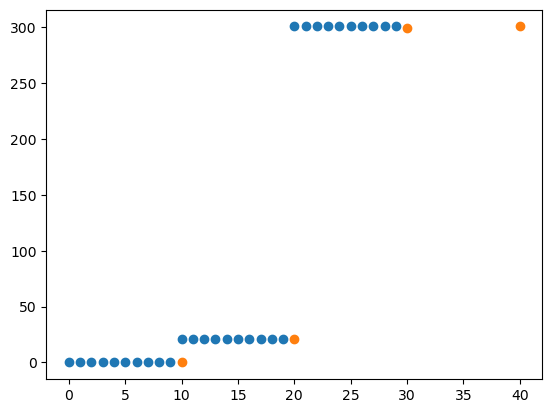

In [109]:
memory_indices = [0, 1, 3]
N_memory_features = len(memory_indices)
N_features = 4
past_timesteps = 10
X_lag = X.permute(1, 2, 0)  # change dimension order to (time, coord, variable)
#X_lag = X_lag[:, :, memory_indices]  # select only the variables that you want add to your memory representation 
X_lag = X_lag.unfold(0, past_timesteps + 1, 1)  # create lagged features, exclude present timestep to align with X_present
#X_lag  = X_lag.permute(2, 3, 0, 1)

# X_pres = X_lag[:, :, :, -1]
# X_pres = X_pres.reshape(-1, N_features)
# print(X_pres.shape)
X_lag = X_lag.reshape(-1, N_features * (past_timesteps + 1))
X_present = X_lag[:, mask_present]
X_lag = X_lag[:, mask_memory]

print(X_lag.shape, X_present.shape)
#X_lag = X_lag.reshape(X_lag.shape[0], -1)
#X_lag = X_lag.permute(2, 0, 1)



coord = 12345
var = 1
t = np.arange(0, 11, 1)
# plt.plot(X_lag[0, coord, var, :].numpy())
# plt.plot(X_lag[3, coord, var, :].numpy())
# plt.plot(X_lag[5, coord, var, :].numpy())
# plt.scatter([10, 10, 10], X_present[[0, 3, 5], coord, var])
# X_lag = X_lag.reshape(-1, N_memory_features, past_timesteps)
# X_lag.shape
plt.scatter(list(range(N_memory_features * past_timesteps)), X_lag.numpy()[coord, :])
plt.scatter([10, 20, 30, 40], X_present[coord])
print(X_lag.numpy()[coord, :])
print(X_present[coord])
#plt.ylim(0, 0.03)

In [27]:
X_lag[5, coord, var, :].numpy()

array([300.52817, 300.52884, 300.52832, 300.5294 , 300.52948, 300.5298 ,
       300.53043, 300.53036, 300.53024, 300.53073], dtype=float32)

tensor(8.8789)